# **IS4487 Week 12 - Practice/Demo Code: Naive Bayes, SVM, Neural Networks**

This notebook is designed to help you follow along with the **Week 12 Reading** on advanced data modeling techniques.
It includes practical code examples for the three machine learning models discussed:

- **Naïve Bayes Classifier** – For spam email detection  
- **Support Vector Machine (SVM)** – For fraud detection  
- **Neural Network** – For fraud detection using deep learning

Each section contains short explanations and annotated code that reflect the steps in the reading.

<a href="https://colab.research.google.com/github/vandanara/UofUtah_IS4487/blob/main/Demos/demo_12_bayes_svm_neural.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



# **ML model: Naïve Bayes: A Probabilistic Classifier**

Naïve Bayes is a simple and efficient supervised machine learning algorithm based on Bayes' Theorem.
It's especially effective in text classification problems like spam filtering, where it calculates the probability
of a class based on feature presence.

### Context: Spam Email Detection
In this example, we use a small set of email text samples. Each email is labeled as either:
- `1` for **Spam** (e.g., containing promotional keywords like "win", "free", "prize")
- `0` for **Not Spam** (e.g., work-related messages like "project", "meeting")

The model learns the patterns of words that typically appear in spam vs. non-spam emails and makes predictions accordingly.


## **Step 1: Import libraries, and obtain data**

We will use a small sample dataset of email headers to demonstrate how the model works.

In [3]:
# Import required libraries for text processing and Naïve Bayes
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Sample email dataset and their corresponding labels (1 = Spam, 0 = Not Spam)
emails = [
    "Win a free lottery ticket now. Act now.",
    "Limited offer! Limited offer. Claim your free prize today",
    "Urgent! Update your bank account details",
    "Meeting tomorrow at 10 AM",
    "Project deadline extended to next week",
    "Hey, can you send me the report?",
    "Congratulations! You won a vacation trip",
    "Special discount just for you, act fast!",
    "Let's schedule a call for the project discussion",
    "Can we reschedule our meeting to next Monday?"
]

# eacb label is associated with a email header shown above in order
labels = [1, 1, 1, 0, 0, 0, 1, 1, 0, 0]

## **Step 2: Prepare Data for the model**

In this step, we perofmr any pre-processing necessary to get the data ready for the ML model. ML models cannot handle text, so we need a way to convert text into numeric data that still somehow can capture the meaning/diversity of the words.

We will use the class CountVectorizer(), which converts a collection of text documents to a matrix of token counts. So each of the email header will be converted into a vector of counts of all the words present in the collection.

It works by tokenizing the text, building a vocabulary of unique words, and then counting the occurrences of each word in each document. This creates a matrix where each row is a document and each column is a word from the vocabulary, with the cell values representing the word's frequency. This matrix can then be used as input for machine learning models.


In [4]:
# Convert text into numeric vectors using Bag of Words (CountVectorizer)
vectorizer = CountVectorizer()
X = vectorizer.fit_transform(emails)

# let us visualize X

#set display to show as many cols as needed without hiding some
pd.set_option('display.max_columns', None)

X_df = pd.DataFrame(data= X.toarray(), columns = vectorizer.get_feature_names_out())
display(X_df)


,10,account,act,am,at,bank,call,can,claim,congratulations,deadline,details,discount,discussion,extended,fast,for,free,hey,just,let,limited,lottery,me,meeting,monday,next,now,offer,our,prize,project,report,reschedule,schedule,send,special,the,ticket,to,today,tomorrow,trip,update,urgent,vacation,we,week,win,won,you,your
0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,2,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0
1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,2,0,0,0,0,0,0,2,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1
2,0,1,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,1
3,1,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0
5,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0
6,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,1,1,0
7,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,1,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0
8,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0
9,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,1,0,0,1,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0


## **Step 3: Split Dataset into Training and Testing**

We will identify the features (input variables `X`) and the target label (output variable `labels`) for our classification task.
`X` is the matrix of 0s and 1s created above.

In [5]:
# Split the dataset into training and testing sets (70/30 split)
X_train, X_test, y_train, y_test = train_test_split(X, labels, test_size=0.3, random_state=41)

## **Step 4: Create and Fit Model**


Scikit-learn (sklearn) offers several implementations of Naive Bayes classifiers, each suited for different types of data and assumptions about feature distributions. The main variants available in sklearn.naive_bayes are:

* **Gaussian Naive Bayes (GaussianNB):** Assumes that continuous features associated with each class are drawn from a Gaussian (normal) distribution.
* **Multinomial Naive Bayes (MultinomialNB):** Assumes that features are drawn from a multinomial distribution. It's typically used for discrete counts, such as word counts in natural language processing (NLP) tasks like text classification, spam filtering, and sentiment analysis, where features represent frequencies or counts.
* **Bernoulli Naive Bayes (BernoulliNB)**: Assumes that features are binary (0 or 1), representing the presence or absence of a particular feature. Example, where the presence or absence of a word matters, rather than its frequency. It can also handle features that are not strictly binary by applying a binarization threshold.
* **Categorical Naive Bayes (CategoricalNB)**: Designed to handle categorical features, where each feature can take on a finite number of discrete values, such as color, size, or type.

These variants provide flexibility in choosing the most appropriate Naive Bayes model based on the characteristics of your dataset and the nature of your features. Since our features are counts (even though most are 0s and 1s, if you look carefully you will see that emails 1 and 2 do have some counts of 2), the best choice of `MultinomialNB()`

In [6]:
# Initialize and train a Multinomial Naïve Bayes classifier
model = MultinomialNB()
model.fit(X_train, y_train)

MultinomialNB()

## **Step 5: Evaluate Model**

Since the data is balanced in the target, we can use accuracy. Otherwise if the class = 1 is a minority, use F1 score, precision and recall.

In [7]:
# Predict on the test set and evaluate accuracy
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

# Print test results and model performance
print("=== Spam Email Classifier Results ===\n")
for email, pred in zip(vectorizer.inverse_transform(X_test), y_pred):
    print(f"Email Words: {email} --> Predicted as {'Spam' if pred == 1 else 'Not Spam'}")

print("\nModel Accuracy:", round(accuracy * 100, 2), "%")

=== Spam Email Classifier Results ===

Email Words: ['hey' 'can' 'you' 'send' 'me' 'the' 'report'] --> Predicted as Not Spam
Email Words: ['you' 'congratulations' 'won' 'vacation' 'trip'] --> Predicted as Not Spam
Email Words: ['act' 'you' 'special' 'discount' 'just' 'for' 'fast'] --> Predicted as Spam

Model Accuracy: 66.67 %


Final note on Naive Bayes:

When working with a mix of count, binary, and continuous features in a Naive Bayes classifier, you can leverage the conditional independence assumption of Naive Bayes to combine different models. The core idea is to use the appropriate Naive Bayes variant for each feature type and then combine their likelihood.

Email Words: ['meeting' 'tomorrow' 'at' '10' 'am'] --> Predicted as Not Spam

Email Words: ['project' 'the' 'for' 'let' 'schedule' 'call' 'discussion'] --> Predicted as Not Spam

Email Words: ['act' 'you' 'special' 'discount' 'just' 'for' 'fast'] --> Predicted as Spam

# **ML Model: Support Vector Machine (SVM): Finding the Optimal Hyperplane**

SVM is a powerful classification algorithm that works by finding a hyperplane that best separates the classes.
It performs well on high-dimensional data and can use kernel functions to handle non-linear boundaries.

#### Context: Fraud Detection (Structured Data)
This example uses a synthetic dataset of 1,000 credit card transactions. Each transaction is labeled as:
- `0` for **Legitimate** transactions (lower amounts, moderate frequency, older accounts)
- `1` for **Fraudulent** transactions (high amounts, frequent activity, newly opened accounts)

SVM tries to distinguish between the two classes based on three features: transaction amount, frequency, and account age.


## **Step 1: Import libraries, and obtain data**

We will generate a sample dataset with 3 features - transaction amount, frequency and account age, and one target, label, to indicate fraud (=1) to demonstrate how the model works.

In [49]:
# Import required libraries for data generation, visualization, and modeling
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix, classification_report

# Generate synthetic dataset for fraud detection with 3 columns and 1 target column
# there will be 100 fraud observations and 900 non-fraud observation
np.random.seed(42)
legit_transactions = np.random.normal(loc=[50, 5, 7], scale=[15, 3, 4], size=(900, 3))
fraud_transactions = np.random.normal(loc=[90, 10, 3], scale=[20, 5, 2], size=(100, 3))

X = np.vstack((legit_transactions, fraud_transactions))
y = np.array([0]*900 + [1]*100)

X_df = pd.DataFrame(data= X, columns = ["Transaction Amount", "Frequency", "Account Age"])
y_df = pd.DataFrame(data= y, columns = ["Label"])
hstack_df = pd.concat([X_df, y_df], axis=1)
hstack_df.describe()

,Transaction Amount,Frequency,Account Age,Label
count,1000.000000,1000.000000,1000.000000,1000.00000
mean,54.856545,5.466433,6.774594,0.10000
std,19.443331,3.567976,3.967350,0.30015
min,5.894170,-4.955680,-5.078049,0.00000
25%,42.349608,3.056001,3.928252,0.00000
50%,53.138923,5.211269,6.774571,0.00000
75%,64.019893,7.469550,9.429307,0.00000
max,168.524754,22.058383,22.410926,1.00000


## **Step 2: Prepare Data for the model**

For SVM, it is essential to standardize the features so they are of the same scale. SVMs are distance-based models, where the model computes distances between data points, and margins that depend on these distances.

If one feature has a larger numeric range than others (e.g., income = 0-100000 vs age = 0-100), the bigger-range feature dominates the distance, causing the SVM to give it more importance even if it's not actually important.

In [50]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler() # Create an instance of StandardScaler
X_scaled = scaler.fit_transform(X_df)

## **Step 3: Split Dataset into Training and Testing**

In [51]:
# Split dataset and normalize features
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42, stratify =y)

## **Step 4: Create and Fit Model**

SVM has a few hyperparameters that you can select values for.
- *C regularization parameter*: Strength of regularization (leniency) is inverse of C.
    - Often we can try powers of 10 (10^-2, 10^-1, 10, 10^1, 10^2 etc), then narrow down using power of 2
- *gamma*: how strong the influence of a point is around itself in non-linear kernels such as poly and rbf
- *kernel*: linear, rbf, poly, sigmoid

In [66]:
# Train the SVM with RBF kernel
svm = SVC(kernel='rbf', gamma='scale', C=10, random_state=42)
svm.fit(X_train, y_train)

SVC(C=10, random_state=42)

## **Step 5: Evaluate Model**

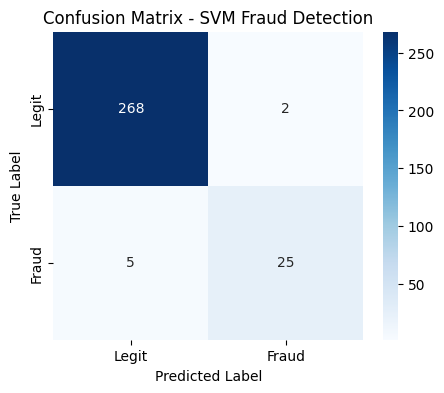

              precision    recall  f1-score   support

       Legit       0.98      0.99      0.99       270
       Fraud       0.93      0.83      0.88        30

    accuracy                           0.98       300
   macro avg       0.95      0.91      0.93       300
weighted avg       0.98      0.98      0.98       300


Accuracy for All: 0.977
Precision for Minority Class (Fraud): 0.926
Recall for Minority Class (Fraud): 0.833
F1 Score for Minority Class (Fraud): 0.877


In [67]:
# Predict
y_pred = svm.predict(X_test)

# evaluate
conf_matrix = confusion_matrix(y_test, y_pred)

# Plot the confusion matrix
plt.figure(figsize=(5, 4))
sns.heatmap(conf_matrix, annot=True, cmap="Blues", fmt="d", xticklabels=["Legit", "Fraud"], yticklabels=["Legit", "Fraud"])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - SVM Fraud Detection")
plt.show()

# Print classification report and accuracy
print(classification_report(y_test, y_pred, target_names=["Legit", "Fraud"]))
accuracy = accuracy_score(y_test, y_pred)
minority_precision = precision_score(y_test, y_pred, pos_label =1)
minority_recall = recall_score(y_test, y_pred, pos_label =1)
minority_f1score = f1_score(y_test, y_pred, pos_label =1)
print(f"\nAccuracy for All: {accuracy:.3f}")
print(f"Precision for Minority Class (Fraud): {minority_precision:.3f}")
print(f"Recall for Minority Class (Fraud): {minority_recall:.3f}")
print(f"F1 Score for Minority Class (Fraud): {minority_f1score:.3f}")



SVM Results:
- since fraud is a minority class (ony 10%), overall accuracy here of 98% is very misleading.
- the best score is recall, which tells us how many of the true fraud cases were caught or predicted to be fraudulent, which is 83%.
- we can also use f1-score, which is a harmonic mean of precision and recall for the fraud(minority) class which is 88%. Precision is defined as: of all the fraud cases predicted, how many were actually fraudulent.

The best scores for minority class were obtained using a `C=10` and `kernel=rbf`.

# **ML model: Neural Networks: Learning Complex Patterns**

Neural Networks consist of layers of interconnected nodes (neurons) that transform inputs through weighted connections.
They are highly flexible and powerful for detecting complex relationships, especially in structured and unstructured data.

#### Context: Fraud Detection Using Deep Learning
Using the same synthetic dataset as the SVM example, this neural network attempts to learn patterns that indicate fraudulent transactions.
Neural networks are especially useful when the relationship between input features and outcomes is non-linear or more complex.


## **Step 1: Import libraries**


In [2]:
# Import required TensorFlow modules for neural networks
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense



## **Step 2: Prepare the Data for the model**

Nothing to be done here, as we have already scaled the features.


## **Step 3: Split Dataset into Training and Testing**

In [13]:
# Reuse existing dataset and normalize again for neural network
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42, stratify=y)


## **Step 4: Create and fit model**

We need to specify each *layer* in the neural network. The input layer with N=3 features, one or more hidden layers are in the middle, and the final output layer. This is defined using `Sequential()` class, made up of several `Dense()` class objects, one for each layer. How to select number of neurons in each layer?
- Hidden layers: each specfied layer except last is hidden. number of neurons is typically specified in powers of 2.
- Input layer: The number of neurons in the input layer is equal to the number of features in the data. This is specified in the first hidden layer as `input_shape()`
- Output layer:  number of neurons in the output depends on whether the model is used as a regressor or classifier. Since we are predicting a binary outcome, we only need one neuron (K-1 where K is number of output classes) in the output layer. In regression we need one neuron per continuous output.

Each later needs an *activation function*. How to choose?
- for input and hidden layers: generally choose ReLU (Rectified Linear Unit). It is the common and efficient default choice, especially in deep networks, because it helps with faster training and avoids the vanishing gradient problem.

- for output layer: consider your output layer's purpose (e.g., use linear for regression, sigmoid for binary classification, or softmax for multi-class classification)

Experimentation is key, as the best choice can depend on the specific problem and network architecture

In [103]:
# Build the neural network model with two hidden layers
model = Sequential([
    Dense(16, activation='relu', input_shape=(3,)),  # First hidden layer, where we specify that input layer has 3 features
    Dense(8, activation='relu'),                     # Second hidden layer
    Dense(1, activation='sigmoid')                   # Output layer (binary classification)
])

# Compile the model with optimizer and loss function. For binary classification, we use binary_crossentropy
# for metrics, we will use both accuracy and recall (since fraud is a minority class)
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy', 'Recall'])

# Train the model and store training history: verbose will print each iteration's stats out
# epochs is number of passes, batch_size is how many obersvations to process before updating weights
history = model.fit(X_train, y_train, epochs=25, batch_size=16, validation_data=(X_test, y_test), verbose=1)

Epoch 1/25


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


44/44 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - Recall: 0.8145 - accuracy: 0.3158 - loss: 0.7584 - val_Recall: 0.5667 - val_accuracy: 0.7467 - val_loss: 0.6291
Epoch 2/25
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - Recall: 0.4360 - accuracy: 0.8376 - loss: 0.6004 - val_Recall: 0.3667 - val_accuracy: 0.9367 - val_loss: 0.5138
Epoch 3/25
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - Recall: 0.4049 - accuracy: 0.9419 - loss: 0.4750 - val_Recall: 0.4333 - val_accuracy: 0.9433 - val_loss: 0.3985
Epoch 4/25
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - Recall: 0.4527 - accuracy: 0.9507 - loss: 0.3597 - val_Recall: 0.4667 - val_accuracy: 0.9467 - val_loss: 0.2911
Epoch 5/25
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - Recall: 0.6282 - accuracy: 0.9584 - loss: 0.2528 - val_Recall: 0.5333 - val_accuracy: 0.9533 - val_loss: 0.2159
Epoch 6/25
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - Recall: 0.6244 - accuracy: 0.9551 - loss: 0.1873 - val_Recall: 0.5333 - val_accuracy: 0.9533 - val_loss: 0.1757
Epoch 7/25
44/44 ━━━━━━━━━

## **Step 5: Evaluate Model**

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 


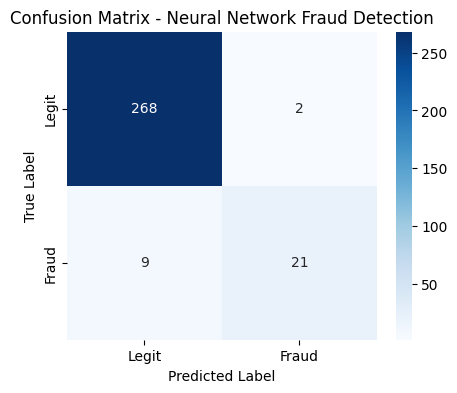

              precision    recall  f1-score   support

       Legit       0.97      0.99      0.98       270
       Fraud       0.91      0.70      0.79        30

    accuracy                           0.96       300
   macro avg       0.94      0.85      0.89       300
weighted avg       0.96      0.96      0.96       300


Accuracy for All: 0.963
Precision for Minority Class (Fraud): 0.913
Recall for Minority Class (Fraud): 0.700
F1 Score for Minority Class (Fraud): 0.792


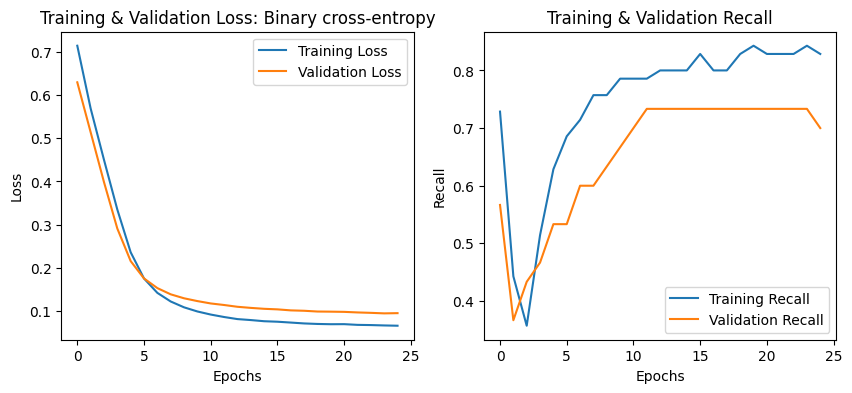

In [104]:
# make prediction
y_pred = (model.predict(X_test) > 0.5).astype(int)

# Evaluate performance
conf_matrix = confusion_matrix(y_test, y_pred)

# Plot the confusion matrix
plt.figure(figsize=(5, 4))
sns.heatmap(conf_matrix, annot=True, cmap="Blues", fmt="d", xticklabels=["Legit", "Fraud"], yticklabels=["Legit", "Fraud"])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Neural Network Fraud Detection")
plt.show()

# Print classification report and calculate metrics
print(classification_report(y_test, y_pred, target_names=["Legit", "Fraud"]))

accuracy = accuracy_score(y_test, y_pred)
minority_precision = precision_score(y_test, y_pred, pos_label =1)
minority_recall = recall_score(y_test, y_pred, pos_label =1)
minority_f1score = f1_score(y_test, y_pred, pos_label =1)
print(f"\nAccuracy for All: {accuracy:.3f}")
print(f"Recall for Minority Class (Fraud): {minority_recall:.3f}")


# Plot training/validation loss and accuracy over epochs
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training & Validation Loss: Binary cross-entropy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['Recall'], label='Training Recall')
plt.plot(history.history['val_Recall'], label='Validation Recall')
plt.xlabel('Epochs')
plt.ylabel('Recall')
plt.title('Training & Validation Recall')
plt.legend()
plt.show()

## **Step 6: Tune the neural net**

Let us try to rerun a different neural network with a third hidden layer, starting with more neurons in the first hidden layer. We will also try an early stopping rule

Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


44/44 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - Recall: 0.0000e+00 - accuracy: 0.8654 - loss: 0.6072 - val_Recall: 0.0000e+00 - val_accuracy: 0.9000 - val_loss: 0.4405
Epoch 2/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - Recall: 0.0000e+00 - accuracy: 0.9133 - loss: 0.3756 - val_Recall: 0.0000e+00 - val_accuracy: 0.9000 - val_loss: 0.2826
Epoch 3/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - Recall: 0.0525 - accuracy: 0.8924 - loss: 0.2612 - val_Recall: 0.3667 - val_accuracy: 0.9367 - val_loss: 0.1923
Epoch 4/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - Recall: 0.5756 - accuracy: 0.9487 - loss: 0.1670 - val_Recall: 0.5000 - val_accuracy: 0.9500 - val_loss: 0.1528
Epoch 5/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - Recall: 0.7636 - accuracy: 0.9743 - loss: 0.1126 - val_Recall: 0.6667 - val_accuracy: 0.9567 - val_loss: 0.1314
Epoch 6/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - Recall: 0.7668 - accuracy: 0.9648 - loss: 0.0926 - val_Recall: 0.7333 - val_accuracy: 0.9567 - val_loss: 0.1134
Epoch

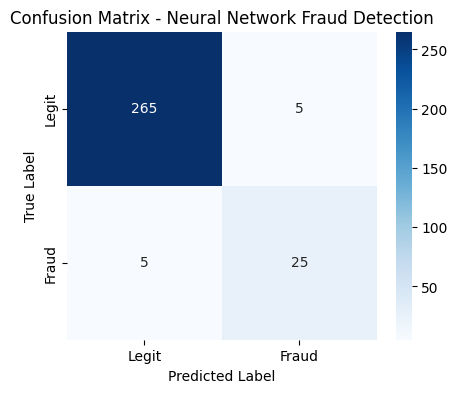

              precision    recall  f1-score   support

       Legit       0.98      0.98      0.98       270
       Fraud       0.83      0.83      0.83        30

    accuracy                           0.97       300
   macro avg       0.91      0.91      0.91       300
weighted avg       0.97      0.97      0.97       300


Accuracy for All: 0.967
Precision for Minority Class (Fraud): 0.833
Recall for Minority Class (Fraud): 0.833
F1 Score for Minority Class (Fraud): 0.833


In [105]:
# Build the neural network model with three hidden layers
model = Sequential([
    Dense(32, activation='relu', input_shape=(3,)),  # First hidden layer, where we specify that input layer has 3 features
    Dense(16, activation='relu'),                    # Second hidden layer
    Dense(8, activation='relu'),                     # third hidden layer
    Dense(1, activation='sigmoid')                   # Output layer (binary classification)
])

# Compile the model with optimizer and loss function. For binary classification, we use binary_crossentropy
# for metrics, we will use both accuracy and recall (since fraud is a minority class)
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy', 'Recall'])

# Define Early Stopping callback
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_Recall',  # Corrected: Monitor validation recall with capital 'R'
    patience=20,           # Stop if val_Recall doesn't improve for 20 epochs
    mode='max',            # Look for maximum validation recall
    restore_best_weights=True # Restore model weights from the best epoch
)

# Train the model and store training history: verbose will print each iteration's stats out
# epochs is number of passes, batch_size is how many obersvations to process before updating weights
history = model.fit(X_train, y_train, epochs=100, batch_size=16, validation_data=(X_test, y_test), verbose=1, callbacks=[early_stopping])

# make prediction
y_pred = (model.predict(X_test) > 0.5).astype(int)

# Evaluate performance
conf_matrix = confusion_matrix(y_test, y_pred)

# Plot the confusion matrix
plt.figure(figsize=(5, 4))
sns.heatmap(conf_matrix, annot=True, cmap="Blues", fmt="d", xticklabels=["Legit", "Fraud"], yticklabels=["Legit", "Fraud"])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Neural Network Fraud Detection")
plt.show()

# Print classification report and calculate metrics
print(classification_report(y_test, y_pred, target_names=["Legit", "Fraud"]))

accuracy = accuracy_score(y_test, y_pred)
minority_precision = precision_score(y_test, y_pred, pos_label =1)
minority_recall = recall_score(y_test, y_pred, pos_label =1)
minority_f1score = f1_score(y_test, y_pred, pos_label =1)
print(f"\nAccuracy for All: {accuracy:.3f}")
print(f"Recall for Minority Class (Fraud): {minority_recall:.3f}")



### Neural net results:

We tuned the neural net to include **more hidden layers**, and ran it for **more epochs**. The more it searches (epochs), it is likely that it can find the best parameters, but the risk is that it can also overfit - leading to poor results on the test data. So to prevent **overfitting**, we can use **early stopping** which will force stop training /learning  whne there is no improvementv in the specified metric to monitor (recall).

note that the early stopping actually led the neural net to stop training early, before we reached 100 epochs. In the second version, we obtained a much higher recall of 83% than the first model (70%)

Also in the sec